In [1]:
# Step 0: Imports
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
from segmentation.models.unet import UNet, UNetEDL
from segmentation.data_loaders.isic2018_segmentation_data_loader import get_isic2018_loaders_test
from segmentation.utils.segmentation_loss import bce_loss, evidential_segmentation_loss
from segmentation.utils.segmentation_metrics import dice_score, iou_score, pixel_accuracy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [9]:
# Step 1: Load a small batch from the dataset
train_loader, num_classes = get_isic2018_loaders_test(batch_size=4, num_workers=0)
images, masks = next(iter(train_loader))
images, masks = images.to(device), masks.to(device)
print(f"Images shape: {images.shape}, Masks shape: {masks.shape}")

Images shape: torch.Size([4, 3, 224, 224]), Masks shape: torch.Size([4, 224, 224])


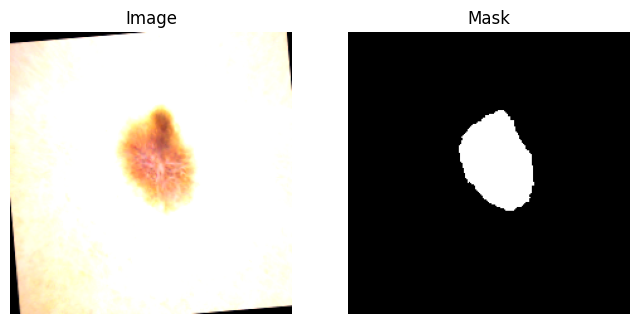

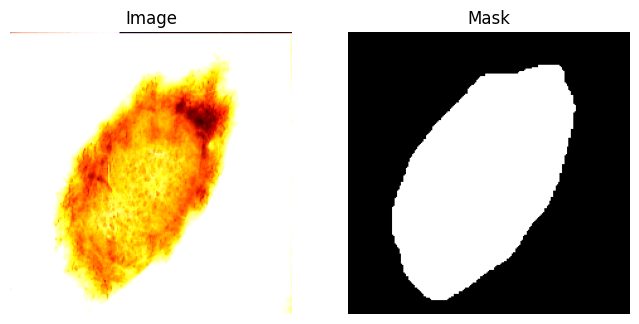

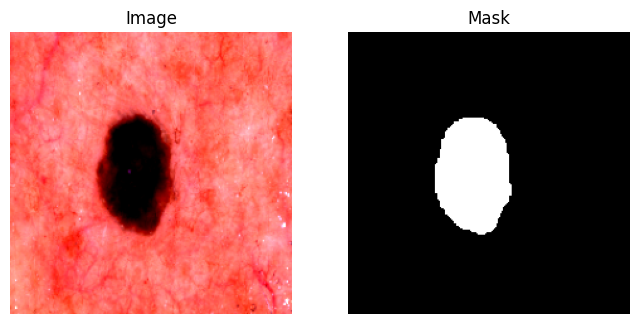

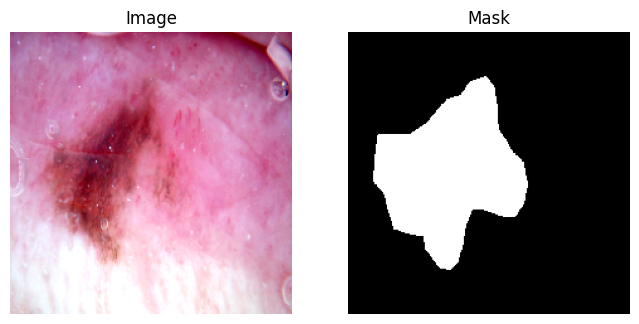

In [10]:
# Step 2: Visualize images and masks
def show_images_masks(images, masks, n=4):
    images = images.cpu().numpy()
    masks = masks.cpu().numpy()
    
    def unnormalize_image(img, mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)):
        img = img.copy()
        for c in range(3):
            img[c] = img[c] * std[c] + mean[c]
        return np.clip(img, 0, 1)
    
    for i in range(n):
        plt.figure(figsize=(8,4))
        plt.subplot(1,2,1)
        plt.imshow(np.transpose(unnormalize_image(images[i]), (1,2,0)))
        plt.title('Image')
        plt.axis('off')
        
        plt.subplot(1,2,2)
        plt.imshow(masks[i], cmap='gray')
        plt.title('Mask')
        plt.axis('off')
        plt.show()

show_images_masks(images, masks)

In [ ]:
# Step 3: Initialize model
model = UNet(n_channels=3, n_classes=num_classes)
model = model.to(device)
model.eval()

UNet(
  (model): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2

In [12]:
# Step 4: Forward pass
with torch.no_grad():
    logits = model(images)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1, keepdim=True)

In [13]:
# Step 5: Compute metrics on batch
dice = dice_score(logits, masks)
iou = iou_score(logits, masks)
acc = pixel_accuracy(logits, masks)
print(f"Dice: {dice:.4f}, IoU: {iou:.4f}, Pixel Accuracy: {acc:.4f}")

Dice: 0.3104, IoU: 0.1837, Pixel Accuracy: 0.1814


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5185375..1.9920369].


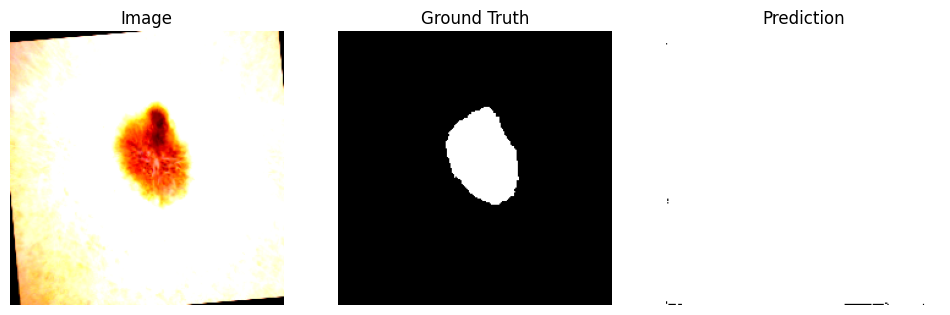

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8606441..2.6399999].


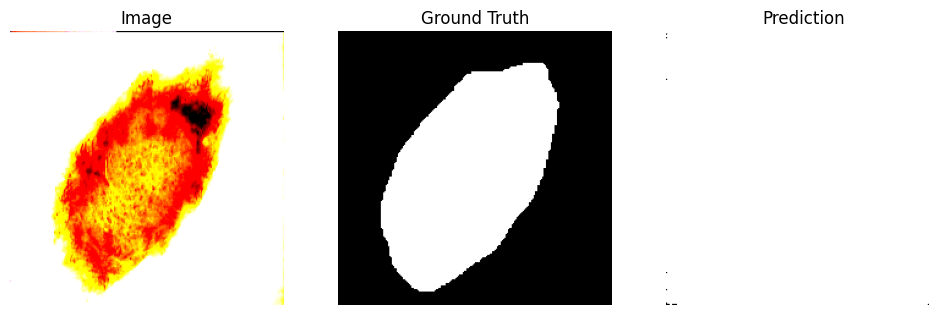

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0357141..2.2489083].


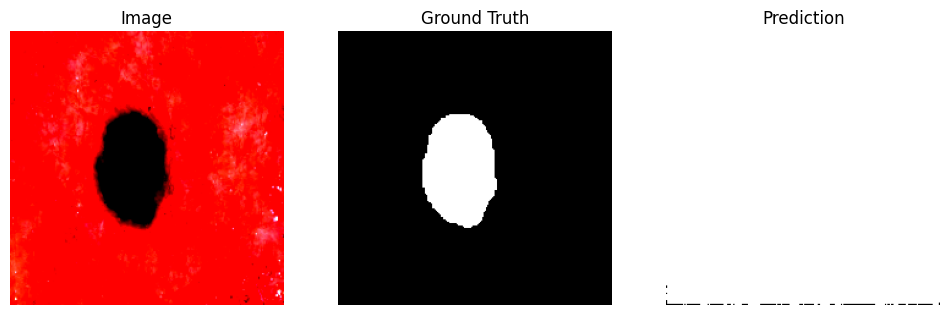

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.4579831..1.5071024].


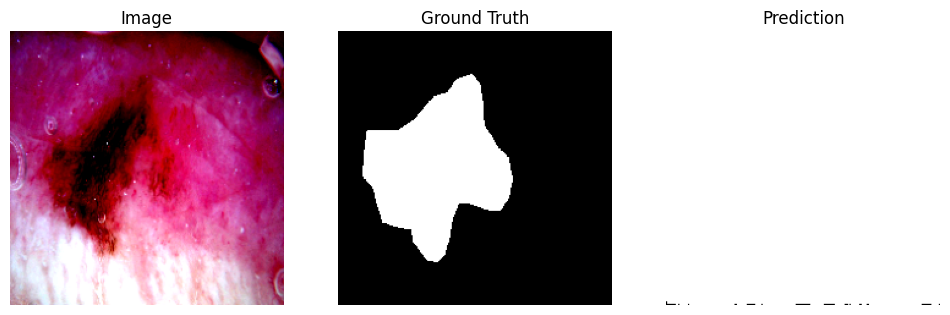

In [16]:
# Step 6: Visualize predictions
def show_predictions(images, masks, preds, n=4):
    images = images.cpu().numpy()
    masks = masks.cpu().numpy()
    preds = preds.cpu().numpy()
    for i in range(n):
        plt.figure(figsize=(12,4))
        plt.subplot(1,3,1)
        plt.imshow(np.transpose(images[i], (1,2,0)))
        plt.title('Image')
        plt.axis('off')
        plt.subplot(1,3,2)
        plt.imshow(masks[i], cmap='gray')
        plt.title('Ground Truth')
        plt.axis('off')
        plt.subplot(1,3,3)
        plt.imshow(preds[i,0], cmap='gray')
        plt.title('Prediction')
        plt.axis('off')
        plt.show()

show_predictions(images, masks, preds)

In [17]:
# Step 7: Overfit small batch
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
for step in range(50):
    model.train()
    optimizer.zero_grad()
    logits = model(images)
    loss = bce_loss(logits, masks)
    loss.backward()
    optimizer.step()
    if step % 10 == 0:
        dice = dice_score(logits, masks)
        print(f"Step {step}, Loss: {loss.item():.4f}, Dice: {dice:.4f}")

Step 0, Loss: 0.9524, Dice: 0.3134
Step 10, Loss: 0.1872, Dice: 0.6741
Step 20, Loss: 0.0805, Dice: 0.8224
Step 30, Loss: 0.0442, Dice: 0.8947
Step 40, Loss: 0.0335, Dice: 0.9246


In [18]:
# Step 8: Check preprocessing consistency
# Verify that images and masks are same size and masks are binary/class-indexed
print("Image min/max:", images.min().item(), images.max().item())
print("Mask unique values:", torch.unique(masks))

Image min/max: -2.0357141494750977 2.6399998664855957
Mask unique values: tensor([0, 1], device='cuda:0', dtype=torch.uint8)
